<a href="https://colab.research.google.com/github/alex-degarate/DAnalytics/blob/main/After_15/ej15_01b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import seaborn as sns
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

#print( matplotlib.__version__)
#print(f"Seaborn version: {sns.__version__}")

url = "https://github.com/alex-degarate/DAnalytics/raw/refs/heads/main/After_15/"

df_pp_ventas = pd.read_csv( url + "ventas_por_region.csv")

Seaborn version: 0.13.2


In [11]:
# revisar DF
df_pp_ventas.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   fecha     1000 non-null   object
 1   producto  1000 non-null   object
 2   region    1000 non-null   object
 3   ventas    1000 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB


In [12]:
df_pp_ventas.head()

,fecha,producto,region,ventas
0,2025-03-24,Auriculares,Este,$9984.02
1,2024-11-04,Smart TV,Este,$8723.07
2,2025-05-14,Auriculares,Oeste,$11326.45
3,2025-04-21,Smart TV,Centro,$7404.36
4,2025-05-18,Smartphone,Oeste,$9358.53


In [13]:
# convertir texto ventas a float
df_pp_ventas ["ventas"] = df_pp_ventas ["ventas"].str.replace('$','', regex=False)
df_pp_ventas ["ventas"] = df_pp_ventas ["ventas"].astype( "float64")

# convertir text fecha a datetime
df_pp_ventas ["fecha"] = pd.to_datetime( df_pp_ventas ["fecha"])
df_pp_ventas ["fecha"] = df_pp_ventas ["fecha"].dt.strftime("%d/%m/%Y")
df_pp_ventas ["fecha"] = pd.to_datetime( df_pp_ventas ["fecha"])


/tmp/ipython-input-3537654774.py:8: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_pp_ventas ["fecha"] = pd.to_datetime( df_pp_ventas ["fecha"])


In [14]:
print(df_pp_ventas.info() )
print(df_pp_ventas.head() )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   fecha     1000 non-null   datetime64[ns]
 1   producto  1000 non-null   object        
 2   region    1000 non-null   object        
 3   ventas    1000 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 31.4+ KB
None
       fecha     producto  region    ventas
0 2025-03-24  Auriculares    Este   9984.02
1 2024-11-04     Smart TV    Este   8723.07
2 2025-05-14  Auriculares   Oeste  11326.45
3 2025-04-21     Smart TV  Centro   7404.36
4 2025-05-18   Smartphone   Oeste   9358.53


In [15]:
df_pp_ventas["producto"].unique()

array(['Auriculares', 'Smart TV', 'Smartphone', 'Consola de videojuegos',
       'Notebook'], dtype=object)

In [16]:
df_pp_ventas["region"].unique()

array(['Este', 'Oeste', 'Centro', 'Sur', 'norte'], dtype=object)

In [56]:
#df_pp_ventas[ df_pp_ventas["producto"] == "Auriculares"].
tabla_ventas = df_pp_ventas.groupby("producto", as_index=False)["ventas"].sum()

tabla_ventas.info()
tabla_ventas.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   producto  5 non-null      object 
 1   ventas    5 non-null      float64
dtypes: float64(1), object(1)
memory usage: 212.0+ bytes


,producto,ventas
0,Auriculares,1820473.24
1,Consola de videojuegos,1607563.02
2,Notebook,1783246.51
3,Smart TV,1784653.97
4,Smartphone,1704850.39


In [60]:

tabla_ventas["ventas"] = tabla_ventas["ventas"].astype(int)
tabla_ventas["eje_y"] = round(tabla_ventas["ventas"] / 1000000,2)

tabla_ventas.head()

,producto,ventas,eje_y
0,Auriculares,1820473,1.82
1,Consola de videojuegos,1607563,1.61
2,Notebook,1783246,1.78
3,Smart TV,1784653,1.78
4,Smartphone,1704850,1.70


In [63]:
# Ordenar los datos por ventas para resaltar las diferencias
tabla_ventas_sorted = tabla_ventas.sort_values(by='ventas', ascending=False)
tabla_ventas_sorted.head()

,producto,ventas,eje_y
0,Auriculares,1820473,1.82
3,Smart TV,1784653,1.78
2,Notebook,1783246,1.78
4,Smartphone,1704850,1.70
1,Consola de videojuegos,1607563,1.61


['1820473', '1784653', '1783246', '1704850', '1607563']


ValueError: too many values to unpack (expected 2)

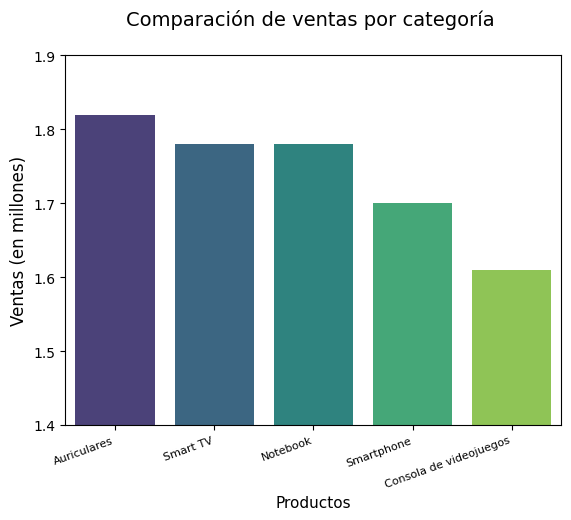

In [100]:
# @title
# Gráfico de barras mejorado en una nueva celda

#plt.figure(figsize=(8, 6)) # Aumentar el tamaño de la figura para mejor visibilidad
ax = sns.barplot(x='producto',y='eje_y', data=tabla_ventas_sorted, hue="producto",
                 legend=False, palette='viridis')

plt.title('Comparación de ventas por categoría \n', fontsize=14)
plt.xlabel('Productos', fontsize=11)
plt.ylabel('Ventas (en millones)', fontsize=12)
plt.xticks(rotation=20, ha='right', fontsize=8)

# Establecer el límite inferior del eje Y en 1 millón
# max_sales = tabla_ventas_sorted['ventas'].max()
# Empieza en 1 millón y el límite superior es un 10% más que la venta máxima
# plt.ylim(1400000, max_sales * 1.02)

plt.ylim(1.40, 1.90)
plt.ticklabel_format(style='plain', axis='y')
ax.yticks = 'eje_y'

#display(ax.containers[0])
#print(ax.containers[1])

info = list(tabla_ventas_sorted["ventas"].astype(str) )
print(info)

# Adding annotations
for i, value in info:
    plt.text(i, value + 5, str(value), ha='center')

'''
# Añadir etiquetas de valor en cada barra
for p in ax.patches:

    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points', fontsize=8)
'''
# Ajustar el diseño para evitar que las etiquetas se superpongan
plt.tight_layout()
plt.show()


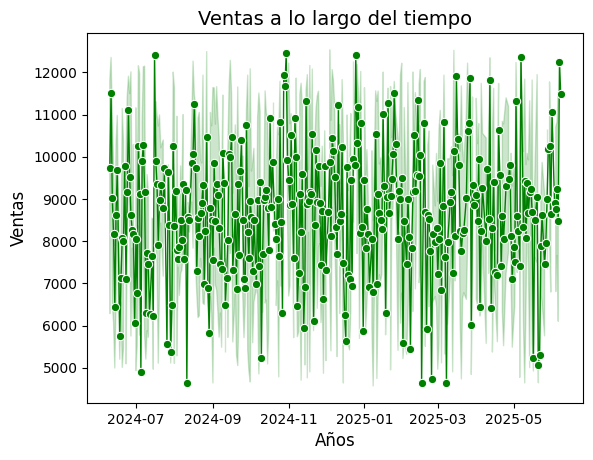

In [7]:

# Gráfico de líneas
sns.lineplot(x='fecha', y='ventas', data=df_pp_ventas, marker='o', color='green',linewidth=1)
plt.title('Ventas a lo largo del tiempo', fontsize=14)
plt.xlabel('Años', fontsize=12)
plt.ylabel('Ventas', fontsize=12)

plt.show()